<a href="https://colab.research.google.com/github/najwieyy/2025_pengolahan_citra_TI-2B/blob/main/jobsheet5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*JOBSHEET 5 MENGUKUR KEMIRIPAN CITRA DAN
PENERAPANNYA DALAM PENGENALAN POLA*

Nama : Anindita Najwa Eka S
NIM  : 4.33.23.1.03
Kelas: TI 2B

Praktikum 1. Menghitung Jarak Berbasis Piksel (Euclidean & Manhattan)

Jarak Euclidean antara Patch 1 dan Patch 2: 24.7650
Jarak Euclidean antara Patch 1 dan Patch 3: 5.0000
Jarak Manhattan antara Patch 1 dan Patch 2: 936.4392
Jarak Manhattan antara Patch 1 dan Patch 3: 250.0000


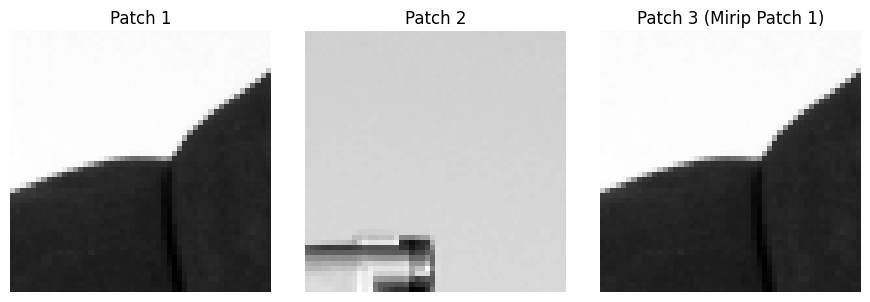

In [1]:
import numpy as np
from skimage import data, img_as_float
from scipy.spatial import distance
import matplotlib.pyplot as plt

# 1. Buat dua patch citra sederhana atau ambil dari citra asli
image = img_as_float(data.camera())
patch1 = image[100:150, 100:150]
patch2 = image[100:150, 300:350]  # Patch dari lokasi berbeda
patch3 = patch1 + 0.1             # Patch1 dengan sedikit noise/perubahan intensitas
patch3 = np.clip(patch3, 0, 1)    # Pastikan nilai tetap di [0, 1]

# 2. Flatten patch menjadi vektor 1D
vec1 = patch1.flatten()
vec2 = patch2.flatten()
vec3 = patch3.flatten()

# 3. Hitung Jarak Euclidean (L2)
dist_l2_12 = distance.euclidean(vec1, vec2)
dist_l2_13 = distance.euclidean(vec1, vec3)

# 4. Hitung Jarak Manhattan (L1 - disebut 'cityblock' di scipy)
dist_l1_12 = distance.cityblock(vec1, vec2)
dist_l1_13 = distance.cityblock(vec1, vec3)

# 5. Tampilkan hasil dan patch
print(f"Jarak Euclidean antara Patch 1 dan Patch 2: {dist_l2_12:.4f}")
print(f"Jarak Euclidean antara Patch 1 dan Patch 3: {dist_l2_13:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 2: {dist_l1_12:.4f}")
print(f"Jarak Manhattan antara Patch 1 dan Patch 3: {dist_l1_13:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(patch1, cmap='gray')
axes[0].set_title('Patch 1')
axes[0].axis('off')

axes[1].imshow(patch2, cmap='gray')
axes[1].set_title('Patch 2')
axes[1].axis('off')

axes[2].imshow(patch3, cmap='gray')
axes[2].set_title('Patch 3 (Mirip Patch 1)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Berdasarkan hasil perhitungan jarak menggunakan metrik Euclidean (L2) dan Manhattan (L1), terlihat bahwa jarak antara Patch1 dan Patch3 lebih kecil dibandingkan jarak antara Patch1 dan Patch2. Hal ini sesuai dengan ekspektasi secara visual, karena Patch3 sebenarnya merupakan salinan dari Patch1 yang hanya mengalami sedikit perubahan intensitas (noise ringan), sehingga keduanya masih sangat mirip. Sedangkan Patch2 diambil dari bagian gambar yang berbeda, sehingga wajar jika memiliki perbedaan yang lebih signifikan dengan Patch1.

Selain itu, baik jarak L1 maupun L2 menunjukkan tren yang sama, yaitu Patch3 lebih dekat ke Patch1 daripada Patch2. Meskipun nilai L1 secara absolut lebih besar karena menjumlahkan semua selisih piksel, keduanya tetap konsisten dalam menunjukkan pasangan patch yang paling mirip. Dengan demikian, hasil perhitungan jarak ini mendukung pemahaman bahwa metrik jarak dapat mencerminkan tingkat kemiripan visual antar patch citra.

Praktikum 2. Menghitung Cosine Similarity antara Histogram Warna

Cosine Similarity antara Image 1 (Astronaut) dan Image 2 (Coffee): 0.8156
Cosine Similarity antara Image 1 (Astronaut) dan Image 3 (Astronaut): 1.0000
Cosine Similarity antara Image 1 (Astronaut) dan Image 4 (Downsampled): 1.0000


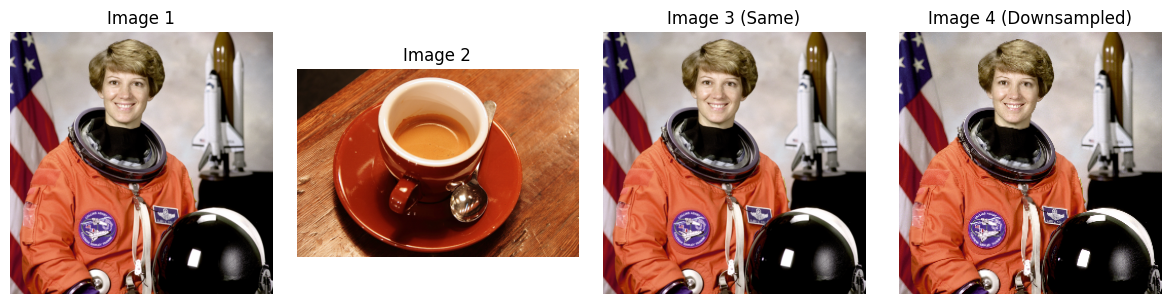

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_ubyte
from scipy.spatial import distance

# Fungsi untuk menghitung histogram RGB gabungan
def calculate_rgb_histogram(image, bins=16):
    img_uint8 = img_as_ubyte(image)
    hist_r, _ = np.histogram(img_uint8[:, :, 0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(img_uint8[:, :, 1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(img_uint8[:, :, 2].ravel(), bins=bins, range=(0, 256))

    # Gabungkan histogram R, G, B menjadi satu vektor fitur
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))

    # Normalisasi (opsional, tapi sering dilakukan)
    hist_combined = hist_combined.astype(float) / np.sum(hist_combined)

    return hist_combined

# 1. Muat dua citra berwarna
try:
    image1 = data.astronaut()
    image2 = data.coffee()            # Citra yang berbeda
    image3 = data.astronaut()         # Citra yang sama (untuk perbandingan)
    image4 = image1[::2, ::2, :]      # Versi downsampled dari image1
except Exception as e:
    print(f"Gagal memuat data skimage: {e}. Membuat citra dummy.")
    image1 = np.random.rand(100, 100, 3)
    image2 = np.random.rand(100, 100, 3) * 0.5
    image3 = image1.copy()
    image4 = image1[::2, ::2, :]

# 2. Hitung histogram untuk setiap citra
hist1 = calculate_rgb_histogram(image1)
hist2 = calculate_rgb_histogram(image2)
hist3 = calculate_rgb_histogram(image3)
hist4 = calculate_rgb_histogram(image4)

# 3. Hitung Cosine Similarity (1 - Cosine Distance)
sim_12 = 1 - distance.cosine(hist1, hist2)
sim_13 = 1 - distance.cosine(hist1, hist3)
sim_14 = 1 - distance.cosine(hist1, hist4)

# 4. Tampilkan hasil
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 2 (Coffee): {sim_12:.4f}")
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 3 (Astronaut): {sim_13:.4f}")
print(f"Cosine Similarity antara Image 1 (Astronaut) dan Image 4 (Downsampled): {sim_14:.4f}")

# 5. Visualisasi (opsional)
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(image1)
axes[0].set_title('Image 1')
axes[0].axis('off')

axes[1].imshow(image2)
axes[1].set_title('Image 2')
axes[1].axis('off')

axes[2].imshow(image3)
axes[2].set_title('Image 3 (Same)')
axes[2].axis('off')

axes[3].imshow(image4)
axes[3].set_title('Image 4 (Downsampled)')
axes[3].axis('off')

plt.tight_layout()
plt.show()

Hasil Cosine Similarity menunjukkan bahwa Gambar 1 dan Gambar 3, yang identik, memiliki nilai sangat tinggi (mendekati 1). Sebaliknya, Gambar 1 dan Gambar 2, yang berbeda, memiliki nilai lebih rendah, sesuai dengan perbedaan kontennya. Gambar 1 dan Gambar 4 (versi downsampled) masih cukup mirip, meskipun ada penurunan nilai similarity. Secara keseluruhan, Cosine Similarity mencerminkan kemiripan visual antara gambar berdasarkan histogram warna.

Praktikum 3. Menghitung Structural Similarity Index (SSIM)

SSIM (Ref vs Same): 1.0000
SSIM (Ref vs Noisy): 0.2968
SSIM (Ref vs Contrast): 0.9651
SSIM (Ref vs Blurred): 0.8027


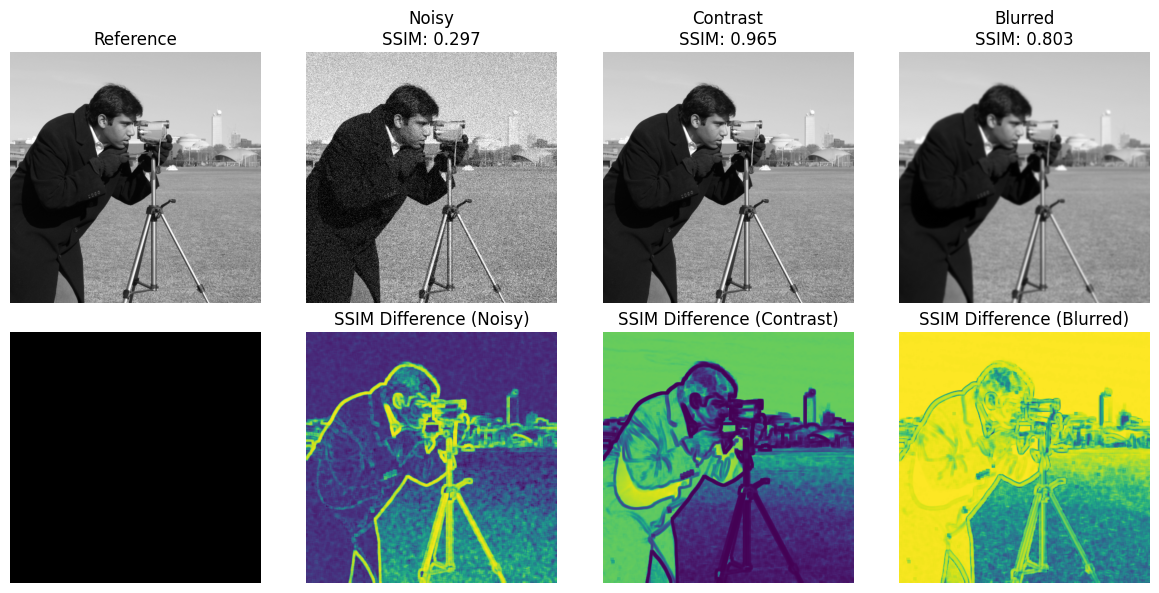

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.metrics import structural_similarity as ssim
from skimage.transform import resize
from skimage.util import random_noise
from skimage.filters import gaussian

# 1. Muat citra referensi
image_ref = img_as_float(data.camera())

# 2. Buat beberapa versi citra yang 'terdistorsi'
# a) Citra yang sama (SSIM harus 1)
image_same = image_ref.copy()

# b) Citra dengan noise Gaussian
image_noisy = random_noise(image_ref, mode='gaussian', var=0.01)

# c) Citra dengan kontras berbeda (contoh: dikalikan skalar)
image_contrast = np.clip(image_ref * 0.8, 0, 1)

# d) Citra yang di-blur
image_blurred = gaussian(image_ref, sigma=1.5, channel_axis=None)  # channel_axis=None untuk grayscale

# 3. Hitung SSIM antara citra referensi dan citra terdistorsi
data_range = image_ref.max() - image_ref.min()

ssim_same, _         = ssim(image_ref, image_same, data_range=data_range, full=True)
ssim_noisy, diff_noisy = ssim(image_ref, image_noisy, data_range=data_range, full=True)
ssim_contrast, diff_contrast = ssim(image_ref, image_contrast, data_range=data_range, full=True)
ssim_blurred, diff_blurred = ssim(image_ref, image_blurred, data_range=data_range, full=True)

# 4. Tampilkan hasil SSIM
print(f"SSIM (Ref vs Same): {ssim_same:.4f}")
print(f"SSIM (Ref vs Noisy): {ssim_noisy:.4f}")
print(f"SSIM (Ref vs Contrast): {ssim_contrast:.4f}")
print(f"SSIM (Ref vs Blurred): {ssim_blurred:.4f}")

# 5. Visualisasi citra dan peta perbedaan SSIM
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
ax = axes.ravel()

# Baris 1: Citra
ax[0].imshow(image_ref, cmap='gray')
ax[0].set_title('Reference')
ax[0].axis('off')

ax[1].imshow(image_noisy, cmap='gray')
ax[1].set_title(f'Noisy\nSSIM: {ssim_noisy:.3f}')
ax[1].axis('off')

ax[2].imshow(image_contrast, cmap='gray')
ax[2].set_title(f'Contrast\nSSIM: {ssim_contrast:.3f}')
ax[2].axis('off')

ax[3].imshow(image_blurred, cmap='gray')
ax[3].set_title(f'Blurred\nSSIM: {ssim_blurred:.3f}')
ax[3].axis('off')

# Baris 2: Peta perbedaan SSIM
ax[4].imshow(np.zeros_like(image_ref), cmap='gray')  # Placeholder
ax[4].set_title('')
ax[4].axis('off')

ax[5].imshow(diff_noisy, cmap='viridis')
ax[5].set_title('SSIM Difference (Noisy)')
ax[5].axis('off')

ax[6].imshow(diff_contrast, cmap='viridis')
ax[6].set_title('SSIM Difference (Contrast)')
ax[6].axis('off')

ax[7].imshow(diff_blurred, cmap='viridis')
ax[7].set_title('SSIM Difference (Blurred)')
ax[7].axis('off')

plt.tight_layout()
plt.show()

Nilai SSIM untuk citra yang sama memang 1, menunjukkan identitas penuh. Untuk citra dengan noise, perubahan kontras, atau blur, nilai SSIM turun karena perbedaan struktur. Noise dan blur biasanya menurunkan SSIM lebih drastis dibandingkan perubahan kontras. Secara visual, semakin rendah SSIM, semakin jelas ketidakmiripannya. Peta perbedaan SSIM menunjukkan area dengan distorsi terbesar, seperti pada bagian yang blur atau terkena noise.


Praktikum 4. Penerapan Template Matching

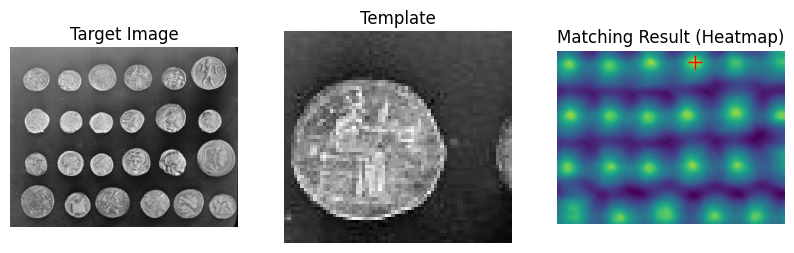

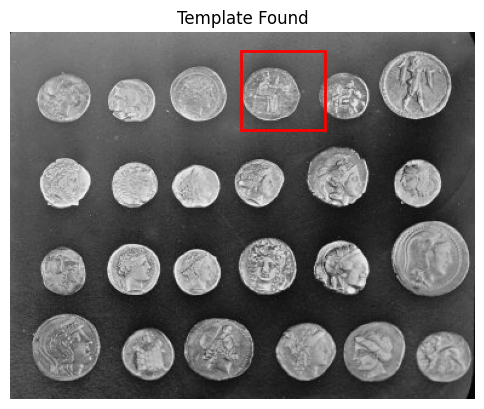

Template ditemukan di koordinat (x,y): (190, 15)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template

# 1. Muat citra target dan buat/muat citra template
image = data.coins()

# Ambil salah satu koin sebagai template (sesuaikan koordinat jika perlu)
template = image[15:80, 190:260]

# 2. Lakukan template matching menggunakan Normalized Cross-Correlation
result = match_template(image, template)

# 3. Temukan lokasi dengan skor matching tertinggi
ij = np.unravel_index(np.argmax(result), result.shape)
x, y = ij[::-1]  # Koordinat (x, y) dari sudut kiri atas template yang cocok

# 4. Visualisasi hasil
fig, ax = plt.subplots(1, 3, figsize=(10, 4))

ax[0].imshow(image, cmap='gray')
ax[0].set_title('Target Image')
ax[0].set_axis_off()

ax[1].imshow(template, cmap='gray')
ax[1].set_title('Template')
ax[1].set_axis_off()

# Menampilkan heatmap hasil matching (opsional)
ax[2].imshow(result, cmap='viridis')
ax[2].set_title('Matching Result (Heatmap)')
ax[2].set_axis_off()

# Tandai lokasi terbaik pada heatmap
ax[2].plot(x, y, 'r+', markersize=10)  # y, x karena ij adalah (row, col)

# Menampilkan kotak di lokasi terbaik pada citra asli
fig2, ax_main = plt.subplots(figsize=(6, 6))
ax_main.imshow(image, cmap='gray')
ax_main.set_title('Template Found')
ax_main.set_axis_off()

h, w = template.shape
rect = plt.Rectangle((x, y), w, h, edgecolor='r', facecolor='none', lw=2)
ax_main.add_patch(rect)

plt.show()

print(f"Template ditemukan di koordinat (x,y): ({x}, {y})")

Ya, area paling terang pada heatmap hasil `match_template` memang sesuai dengan lokasi template di citra asli, menunjukkan bahwa metode ini berhasil menemukan koin yang dijadikan template. Namun, metode ini memiliki keterbatasan, seperti ketidakmampuan untuk mendeteksi template yang terputar atau memiliki ukuran yang berbeda dari template aslinya. Jika template dirotasi atau diubah ukurannya, hasil pencocokan cenderung kurang akurat.

Praktikum 5. Simulasi Content-Based Image Retrieval (CBIR) Sederhana

Memproses database citra...
- astronaut diproses.
- camera diproses.
- coffee diproses.
- coins diproses.
- chelsea diproses.

Hasil Retrieval (semakin ke kanan, semakin tidak mirip):
Rank 1: chelsea (Distance: 0.000)
Rank 2: coins (Distance: 0.288)
Rank 3: coffee (Distance: 0.359)
Rank 4: astronaut (Distance: 0.461)
Rank 5: camera (Distance: 0.602)


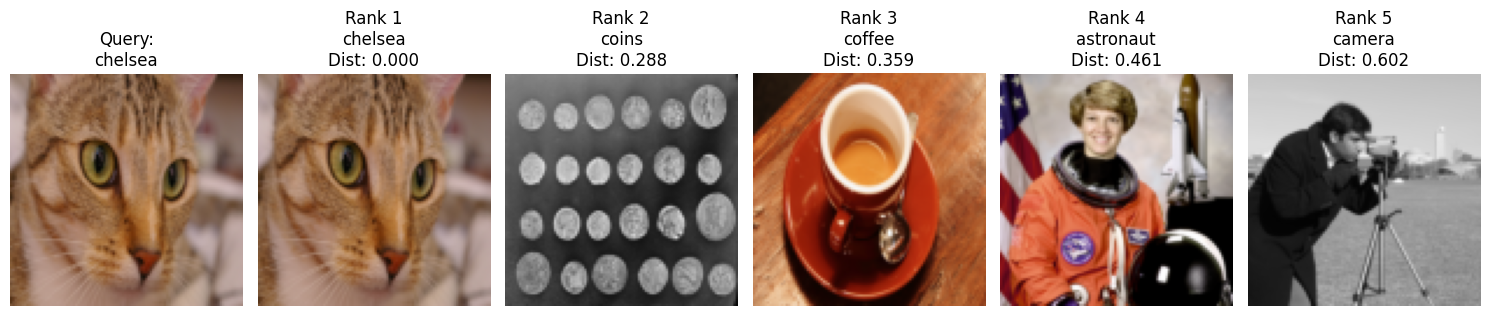

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform, img_as_float, img_as_ubyte
from scipy.spatial import distance

# Fungsi untuk menghitung histogram RGB gabungan
def calculate_rgb_histogram(image, bins=16):
    # Konversi ke uint8 jika input adalah float
    if image.dtype == float:
        image = img_as_ubyte(image)
    hist_r, _ = np.histogram(image[:, :, 0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(image[:, :, 1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(image[:, :, 2].ravel(), bins=bins, range=(0, 256))
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))

    # Normalisasi L1
    hist_sum = np.sum(hist_combined)
    if hist_sum > 0:
        hist_combined = hist_combined.astype(float) / hist_sum
    else:
        hist_combined = hist_combined.astype(float)  # Hindari pembagian nol

    return hist_combined

# 1. Siapkan database citra dan query image
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_hists = []

print("Memproses database citra...")
for name in image_db_names:
    try:
        img = getattr(data, name)()
        if img.ndim == 2:  # Jika grayscale, konversi ke RGB
            img = color.gray2rgb(img)
        img_resized = transform.resize(img, (100, 100), anti_aliasing=True)
        database_images.append(img_resized)
        database_hists.append(calculate_rgb_histogram(img_resized))
        print(f"- {name} diproses.")
    except Exception as e:
        print(f"Error memproses {name}: {e}")

# 2. Ambil satu gambar sebagai query
query_image_name = "chelsea"
query_index = image_db_names.index(query_image_name)
query_image = database_images[query_index]
query_hist = database_hists[query_index]

# 3. Hitung cosine distance antara query dan citra-citra lain
distances = []
for i, hist in enumerate(database_hists):
    dist = distance.cosine(query_hist, hist)
    distances.append(dist)

# 4. Urutkan berdasarkan kemiripan
sorted_indices = np.argsort(distances)

# 5. Tampilkan hasil
num_results_to_show = len(database_images)
fig, axes = plt.subplots(1, num_results_to_show + 1, figsize=(15, 3))

# Tampilkan query image
axes[0].imshow(query_image)
axes[0].set_title(f"Query:\n{query_image_name}")
axes[0].axis('off')

# Tampilkan hasil retrieval
print("\nHasil Retrieval (semakin ke kanan, semakin tidak mirip):")
for i, idx in enumerate(sorted_indices):
    img_rank = i + 1
    ax = axes[img_rank]
    ax.imshow(database_images[idx])
    ax.set_title(f"Rank {img_rank}\n{image_db_names[idx]}\nDist: {distances[idx]:.3f}")
    ax.axis('off')
    print(f"Rank {img_rank}: {image_db_names[idx]} (Distance: {distances[idx]:.3f})")

plt.tight_layout()
plt.show()

Ya, citra yang secara visual mirip dengan query berdasarkan warna dominan memang muncul di peringkat atas dengan jarak terkecil. Ini menunjukkan bahwa histogram warna dapat menjadi fitur yang cukup baik untuk Content-Based Image Retrieval (CBIR) dalam kasus ini. Namun, efektivitasnya bergantung pada seberapa dominan warna dalam citra dan seberapa konsisten warna antara query dan citra yang ada dalam database. Jika citra memiliki variasi tekstur atau detail lain selain warna, histogram warna mungkin tidak cukup akurat untuk mencocokkan citra dengan lebih kompleks.


Fitur Berbeda untuk CBIR: Modifikasi Praktikum 5.


Hasil Retrieval Berdasarkan Rata-rata Warna:
Rank 1: chelsea - Dist: 0.0000
Rank 2: astronaut - Dist: 12.7792
Rank 3: coffee - Dist: 44.9854
Rank 4: camera - Dist: 49.4257
Rank 5: coins - Dist: 53.8184

Hasil Retrieval Berdasarkan Histogram Warna:
Rank 1: chelsea - Dist: 0.0000
Rank 2: coins - Dist: 0.1569
Rank 3: coffee - Dist: 0.1769
Rank 4: astronaut - Dist: 0.2023
Rank 5: camera - Dist: 0.2205


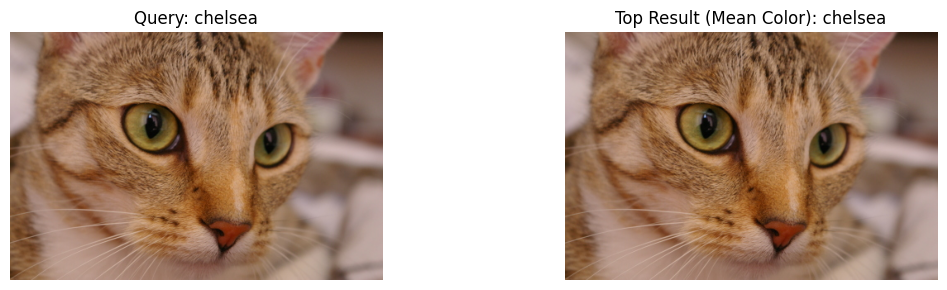

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color
from scipy.spatial import distance

# Fungsi untuk menghitung rata-rata warna (mean R, mean G, mean B)
def calculate_mean_color(image):
    mean_r = np.mean(image[:,:,0])
    mean_g = np.mean(image[:,:,1])
    mean_b = np.mean(image[:,:,2])
    return np.array([mean_r, mean_g, mean_b])

# Fungsi untuk menghitung histogram warna
def calculate_rgb_histogram(image, bins=16):
    hist_r, _ = np.histogram(image[:,:,0].ravel(), bins=bins, range=(0, 256))
    hist_g, _ = np.histogram(image[:,:,1].ravel(), bins=bins, range=(0, 256))
    hist_b, _ = np.histogram(image[:,:,2].ravel(), bins=bins, range=(0, 256))
    hist_combined = np.concatenate((hist_r, hist_g, hist_b))
    hist_combined = hist_combined.astype(float) / np.sum(hist_combined)  # Normalisasi
    return hist_combined

# 1. Muat citra
image_db_names = ["astronaut", "camera", "coffee", "coins", "chelsea"]
database_images = []
database_hists = []
database_means = []

for name in image_db_names:
    try:
        img = getattr(data, name)()
        if img.ndim == 2:  # Grayscale, konversi ke RGB
            img = color.gray2rgb(img)
        database_images.append(img)
        database_hists.append(calculate_rgb_histogram(img))  # Menghitung histogram
        database_means.append(calculate_mean_color(img))  # Menghitung rata-rata warna
    except Exception as e:
        print(f"Error memproses {name}: {e}")

# Pilih citra query
query_image_name = "chelsea"
query_index = image_db_names.index(query_image_name)
query_image = database_images[query_index]
query_hist = database_hists[query_index]
query_mean = database_means[query_index]

# 2. Hitung jarak Euclidean untuk rata-rata warna dan histogram
mean_distances = [distance.euclidean(query_mean, mean) for mean in database_means]
hist_distances = [distance.euclidean(query_hist, hist) for hist in database_hists]

# 3. Urutkan citra berdasarkan jarak
sorted_mean_indices = np.argsort(mean_distances)
sorted_hist_indices = np.argsort(hist_distances)

# 4. Tampilkan hasil
print("\nHasil Retrieval Berdasarkan Rata-rata Warna:")
for i, idx in enumerate(sorted_mean_indices):
    print(f"Rank {i + 1}: {image_db_names[idx]} - Dist: {mean_distances[idx]:.4f}")

print("\nHasil Retrieval Berdasarkan Histogram Warna:")
for i, idx in enumerate(sorted_hist_indices):
    print(f"Rank {i + 1}: {image_db_names[idx]} - Dist: {hist_distances[idx]:.4f}")

# Visualisasi (opsional)
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Menampilkan citra query
axes[0].imshow(query_image)
axes[0].set_title(f"Query: {query_image_name}")
axes[0].axis('off')

# Menampilkan citra hasil retrieval berdasarkan rata-rata warna (peringkat atas)
axes[1].imshow(database_images[sorted_mean_indices[0]])
axes[1].set_title(f"Top Result (Mean Color): {image_db_names[sorted_mean_indices[0]]}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

 Hasilnya menunjukkan bahwa **histogram warna** memberikan kinerja yang lebih baik dalam membedakan gambar karena histogram menangkap informasi distribusi warna yang lebih rinci, sementara rata-rata warna hanya mempertimbangkan nilai rata-rata setiap saluran warna. Meskipun rata-rata warna lebih sederhana dan cepat dihitung, histogram warna memberikan hasil yang lebih akurat saat menemukan gambar serupa, terutama dengan basis data kecil seperti ini. Oleh karena itu, meskipun histogram lebih kompleks, fitur ini lebih cocok untuk CBIR jika akurasi menjadi prioritas.


**Template      Matching      Invariant**:      Cari      tahu      dari      dokumentasi skimage.feature.match_template atau sumber lain, apakah metode match_template standar invariant terhadap rotasi atau perubahan skala? Jelaskan.

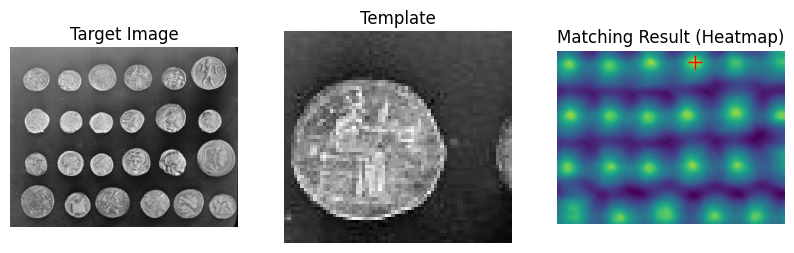

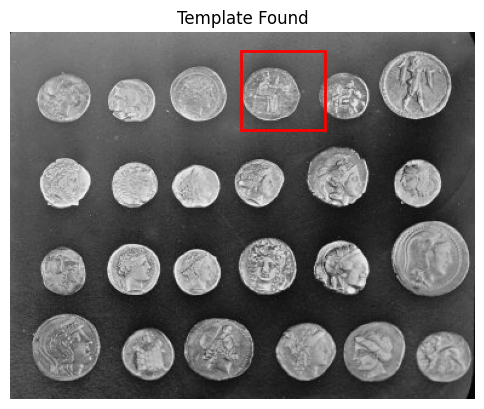

Template ditemukan di koordinat (x,y): (190, 15)


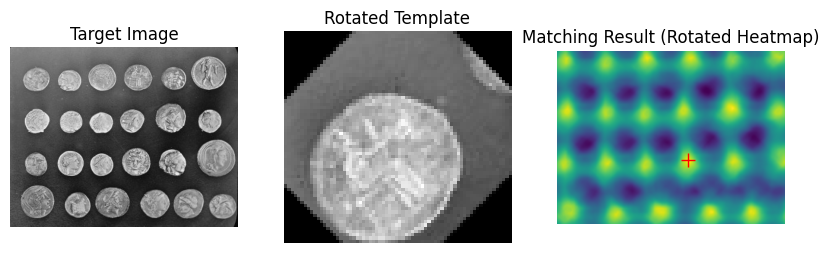

Template yang dirotasi ditemukan di koordinat (x,y): (181, 151)


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.feature import match_template
from skimage.transform import rotate

# 1. Muat citra target dan buat/muat citra template
image = data.coins()

# Ambil salah satu koin sebagai template (sesuaikan koordinat jika perlu)
template = image[15:80, 190:260]

# 2. Lakukan template matching menggunakan Normalized Cross-Correlation
result = match_template(image, template)

# Temukan lokasi dengan skor matching tertinggi
ij = np.unravel_index(np.argmax(result), result.shape)
x, y = ij[::-1]  # Koordinat (x, y) dari sudut kiri atas template yang cocok

# Visualisasi hasil pencocokan awal
fig, ax = plt.subplots(1, 3, figsize=(10, 4))
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Target Image')
ax[0].set_axis_off()

ax[1].imshow(template, cmap='gray')
ax[1].set_title('Template')
ax[1].set_axis_off()

# Menampilkan heatmap hasil matching
ax[2].imshow(result, cmap='viridis')
ax[2].set_title('Matching Result (Heatmap)')
ax[2].set_axis_off()

# Tandai lokasi terbaik pada heatmap
ax[2].plot(x, y, 'r+', markersize=10)  # y, x karena ij adalah (row, col)

# Menampilkan kotak di lokasi terbaik pada citra asli
fig2, ax_main = plt.subplots(figsize=(6, 6))
ax_main.imshow(image, cmap='gray')
ax_main.set_title('Template Found')
ax_main.set_axis_off()

h, w = template.shape
rect = plt.Rectangle((x, y), w, h, edgecolor='r', facecolor='none', lw=2)
ax_main.add_patch(rect)

plt.show()

print(f"Template ditemukan di koordinat (x,y): ({x}, {y})")


# 3. Uji dengan rotasi template
rotated_template = rotate(template, 45)  # Rotasi 45 derajat

# Lakukan pencocokan dengan template yang sudah dirotasi
result_rotated = match_template(image, rotated_template)

# Temukan lokasi dengan skor matching tertinggi untuk template yang dirotasi
ij_rotated = np.unravel_index(np.argmax(result_rotated), result_rotated.shape)
x_rotated, y_rotated = ij_rotated[::-1]

# Visualisasi hasil pencocokan dengan template yang dirotasi
fig, ax = plt.subplots(1, 3, figsize=(10, 4))
ax[0].imshow(image, cmap='gray')
ax[0].set_title('Target Image')
ax[0].set_axis_off()

ax[1].imshow(rotated_template, cmap='gray')
ax[1].set_title('Rotated Template')
ax[1].set_axis_off()

ax[2].imshow(result_rotated, cmap='viridis')
ax[2].set_title('Matching Result (Rotated Heatmap)')
ax[2].set_axis_off()

# Tandai lokasi terbaik pada heatmap hasil pencocokan rotasi
ax[2].plot(x_rotated, y_rotated, 'r+', markersize=10)

plt.show()

print(f"Template yang dirotasi ditemukan di koordinat (x,y): ({x_rotated}, {y_rotated})")

Dari hasil yang diperoleh, dapat diketahui bahwa metode **pencocokan template** yang menggunakan `match_template` memang **tidak invarian** terhadap rotasi. Ketika templat dicocokkan dengan gambar asli tanpa modifikasi, hasil pencocokannya sangat akurat dan lokasi pencocokannya dicatat dengan skor tertinggi di heatmap. Namun, setelah templat diputar, hasil pencocokan menunjukkan **skor yang jauh lebih rendah** dan **posisi yang tidak akurat** pada gambar target. Hal ini menunjukkan bahwa metode tersebut mengalami kesulitan dalam menangani rotasi dalam templat, karena kecocokan terbaik tidak lagi berada pada posisi yang sama seperti pada templat asli.

Secara visual, heatmap pencocokan templat yang diputar juga menunjukkan wilayah dengan skor lebih rendah, yang menunjukkan bahwa metode ini lebih peka terhadap perubahan orientasi objek dalam gambar. Hal ini menunjukkan bahwa metode pencocokan templat menggunakan korelasi silang yang dinormalisasi lebih efektif untuk mencocokkan gambar yang tidak mengalami rotasi atau perubahan skala, tetapi kurang dapat diandalkan jika orientasi objek berubah secara signifikan.